In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def lj_potential(r, sigma, epsilon):
    return 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

In [27]:
def compute_lj_force(r_vec, sigma, epsilon):
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros_like(r_vec)
    force_magnitude = 24 * epsilon * (2 * (sigma**12) / (r**13) - (sigma**6) / (r**7))
    force_vector = force_magnitude * (r_vec / r)
    return force_vector

In [28]:
sigma = 1.0
epsilon = 1.0

a = 2 ** (1 / 6) * sigma  # 平衡距離
n_cells = 2
# initial_positions = np.array([0, a - 0.2, 2 * a])
bases = np.array([[0.0, 0.0], [0.5, 0.5]])

N = 2 * n_cells**2
pos = np.zeros((N, 2))
idx = 0
for ix in range(n_cells):
    for iy in range(n_cells):
        for b in bases:
            pos[idx] = (np.array([ix, iy]) + b) * np.sqrt(2) * a
            idx += 1

num_particles = pos.shape[0]

initial_positions = pos

In [ ]:
# initial_positions[1] += 0.1  # 粒子2をわずかにずらす
initial_velocities = np.zeros_like(initial_positions)
masses = np.ones(num_particles)
total_time = 10.0
num_steps = 10000
dt = total_time / num_steps
pos_T = np.zeros((num_steps, initial_positions.shape[0], initial_positions.shape[1]))
pos_T[0] = initial_positions
pos_T[1] = initial_positions + initial_velocities * dt
box = [
    [0, np.sqrt(2) * a * n_cells],
    [0, np.sqrt(2) * a * n_cells],
]  # シミュレーションボックスの範囲
r_cutoff = 2.5 * sigma  # カットオフ距離

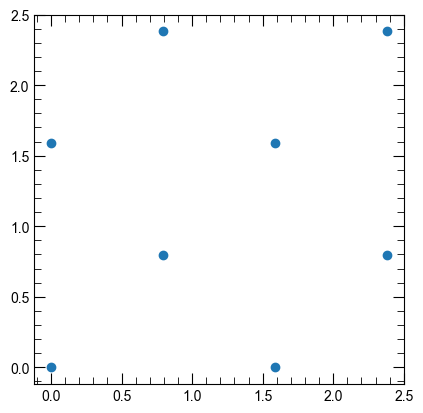

In [ ]:
fig, ax = plt.subplots()
ax.scatter(initial_positions[:, 0], initial_positions[:, 1])
ax.set_aspect("equal")

In [31]:
t = 1
r_vec = pos_T[t, 1] - pos_T[t, 0]
force_on_0 = compute_lj_force(r_vec, sigma, epsilon)
force_on_1 = -force_on_0
print("Force on particle 0 at step", t, ":", force_on_0)
print("Force on particle 1 at step", t, ":", force_on_1)

Force on particle 0 at step 1 : [-9.42055475e-16 -9.42055475e-16]
Force on particle 1 at step 1 : [9.42055475e-16 9.42055475e-16]


In [32]:
def apply_periodic_boundary(r_vec, box):
    L = (
        box[1][1] - box[0][0],
        box[1][1] - box[0][0],
    )  # シミュレーションボックスのサイズ
    for dim in range(len(r_vec)):
        if r_vec[dim] > L[dim] / 2:
            r_vec[dim] -= L[dim]
        elif r_vec[dim] < -L[dim] / 2:
            r_vec[dim] += L[dim]
    return r_vec

In [33]:
num_particles = pos_T.shape[1]
forces_traj = np.zeros(
    (num_steps, initial_positions.shape[0], initial_positions.shape[1])
)
L = np.array([box[1][1] - box[0][0], box[1][1] - box[0][0]])
for t in range(1, num_steps - 1):
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_vec = pos_T[t, i] - pos_T[t, j]
            r_vec = apply_periodic_boundary(r_vec, box)

            force_ij = compute_lj_force(r_vec, sigma, epsilon)

            forces_traj[t, i] += force_ij
            forces_traj[t, j] -= force_ij

    for i in range(num_particles):
        acceleration = forces_traj[t, i] / masses[i]
        pos_T[t + 1, i] = 2 * pos_T[t, i] - pos_T[t - 1, i] + acceleration * dt**2
        pos_T[t + 1, i] = pos_T[t + 1, i] % L  # PBC適用

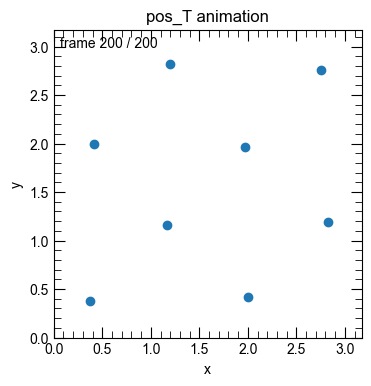

In [34]:
# pos_T をアニメーション化して GIF 保存（/mnt/data/pos_T_animation.gif）
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# 既存の pos_T / box / dt を使う。無ければ簡易デモを作る
g = globals()
if "pos_T" in g:
    pos_T = g["pos_T"]
    if "box" in g and isinstance(g["box"], (list, tuple, np.ndarray)):
        Lx = g["box"][1][1] - g["box"][0][0]
        Ly = g["box"][1][1] - g["box"][0][0]
        L = np.array([Lx, Ly], dtype=float)
    else:
        mins = pos_T.reshape(-1, 2).min(axis=0)
        maxs = pos_T.reshape(-1, 2).max(axis=0)
        span = np.maximum(maxs - mins, 1.0)
        L = span * 1.05
    dt = g.get("dt", 0.02)
else:
    # 超軽量デモ（2粒子）
    T = 300
    t = np.linspace(0, 6.0, T)
    r = 1.0
    x1 = 1.5 + r * np.cos(t)
    y1 = 1.5 + r * np.sin(t)
    x2 = 1.5 + r * np.cos(t + np.pi)
    y2 = 1.5 + r * np.sin(t + np.pi)
    pos_T = np.stack([np.stack([x1, y1], axis=-1), np.stack([x2, y2], axis=-1)], axis=1)
    L = np.array([3.0, 3.0])
    dt = 0.02

T, N, D = pos_T.shape
assert D == 2

# 最大 200 フレームに間引き
n_frames = min(200, T)
frame_idx = np.linspace(0, T - 1, n_frames).astype(int)

fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
scat = ax.scatter(pos_T[frame_idx[0], :, 0], pos_T[frame_idx[0], :, 1])
ax.set_xlim(0, L[0])
ax.set_ylim(0, L[1])
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("pos_T animation")
txt = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", ha="left")


def init():
    scat.set_offsets(pos_T[frame_idx[0]])
    txt.set_text(f"frame 1 / {n_frames}")
    return scat, txt


def update(k):
    f = frame_idx[k]
    scat.set_offsets(pos_T[f])
    txt.set_text(f"frame {k+1} / {n_frames}")
    return scat, txt


ani = animation.FuncAnimation(
    fig, update, frames=np.arange(n_frames), init_func=init, blit=True, interval=50
)

from matplotlib.animation import PillowWriter

ani.save("pos_T_animation.gif", writer=PillowWriter(fps=15), dpi=100)
plt.show()